In [1]:
## This coding is to perform bearing remaining useful life (RUL) estimation
## Dataset: XJTU (3 conditions, 5 bearings per condition)
## In this model, we need to wait ts_input for the RUL prediction to inform the initial trend of health index (HI)
## A weighted function is applied to the loss function to incerase the importance of prediction at the end of the bearing's lifetime
## Three conditions are considered seperately at this moment. We'll focus on the thrid condition with the lowest load in this script.
## In this study, RMS value is treated as the HI. However, the algorithm is independent of the selection of the HI.
## We define the end-of-life (EOL) critera as RMS=5 (g). 
## Training sets: bearing 1 and 2, condition 3
## Testing sets: bearing 3 and 4, condition 3
## Bearing 5,condition 3, is dropped because the remaining dataset is not enough for this task after the redefination of EOL criteria.  

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"

In [2]:
## set the seed for the repeatability 
# Source - https://stackoverflow.com/a/66343730
# Posted by Dan, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-03, License - CC BY-SA 4.0

import tensorflow as tf
import numpy as np
import random

seed = 0
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
tf.random.set_seed(seed)
np.random.seed(seed)

os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

2026-07-02 13:05:53.937568: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-02 13:05:53.937604: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-02 13:05:53.937635: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-02 13:05:53.943981: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-02 13:05:54.611887: W tensorflow/compiler/

### Condition 3

In [3]:
## read matric values
import numpy as np
import pandas as pd
import math
## root for RMS file
root='processed data/'
ts = 3
thres=5 # redefine end of life based on threshold mechanism
## RUL (min) of early fault detection (0.2 threshold)
Alarm = [202,276,27,94,43]


## parameters for RUL estimation
ts_input=3 # Sliding window of RUL model
health_index = 'MAE'
ts_pred = 1 # predict the folling ts_pred timestamp
idx_train = [0,1] # traning bearing indices
idx_test = [2,3] # testing bearing indices, not using bearing 3_5

bearing_list = np.array([f'Bearing3_{j}' for j in range(1,6)])

X_train_list = {}
Y_train_list = {}
for b in idx_train:
    bearing = bearing_list[b]
    filename = os.path.join(root,bearing+'_RMS.csv')
    df = pd.read_csv(filename)
    EOL_index = df.iloc[:,0][df.iloc[:,0].values>thres].index[0] 
    ## In this model, we need to wait ts_input for the RUL prediction to inform the initial trend of HI
    ## */thres for normalization
    ## we use data point exceeding the treshold to train the model
    X_train_list[bearing] = df.iloc[-Alarm[b]:-ts_pred,0]/thres # 0 column for horizontal viration, predict the following ts_pred timestamp
    Y_train_list[bearing] = df.iloc[-Alarm[b]+ts_pred:,0]/thres # predict the following ts_pred timestamp

X_test_list = {}
Y_test_list = {}
for b in idx_test:
    bearing = bearing_list[b]
    filename = os.path.join(root,bearing+'_RMS.csv')
    df = pd.read_csv(filename)
    if b == 2:
        EOL_index = df.iloc[:,0].index[-1]
    else:
        EOL_index = df.iloc[:,0][df.iloc[:,0].values>thres].index[0]-1 # -1 mean before exceeing the threshold
    ## In this model, we need to wait ts_input for the RUL prediction to inform the initial trend of HI
    ## :(EOL_index+1) because the index ends in (EOL_index+1)-1
    # X_test_list[bearing] = df.iloc[-Alarm[b]:-Alarm[b]+ts_input,0]/thres # the X_test will be construced from the prediction
    # Y_test_list[bearing] = df.iloc[-Alarm[b]+ts_input:(EOL_index+1),0]/thres # the X_test will be construced from the prediction
    X_test_list[bearing] = df.iloc[-Alarm[b]:(EOL_index+1)-ts_pred,0]/thres # the X_test will be construced from the prediction
    Y_test_list[bearing] = df.iloc[-Alarm[b]+ts_pred:(EOL_index+1),0]/thres # the X_test will be construced from the prediction


print(bearing_list.shape)
print(bearing_list)
print('first 5 rows of the first X_training set')
print(X_train_list[bearing_list[idx_train[0]]][:5])
print(X_train_list[bearing_list[idx_train[0]]].shape)
print(Y_train_list[bearing_list[idx_train[0]]].shape)
print('first 5 rows of the first Y_testing set')
print(Y_test_list[bearing_list[idx_test[0]]][:5])
print(Y_test_list[bearing_list[idx_test[0]]].shape)
print('first input of X_testing set')
print(X_test_list[bearing_list[idx_test[0]]].shape)


(5,)
['Bearing3_1' 'Bearing3_2' 'Bearing3_3' 'Bearing3_4' 'Bearing3_5']
first 5 rows of the first X_training set
2336    0.102625
2337    0.106402
2338    0.105735
2339    0.107889
2340    0.108275
Name: Horizontal RMS, dtype: float64
(201,)
(201,)
first 5 rows of the first Y_testing set
345    0.664106
346    0.706735
347    0.681284
348    0.625282
349    0.646124
Name: Horizontal RMS, dtype: float64
(26,)
first input of X_testing set
(26,)


In [4]:
## Transform the dataset for LSTM-AE input
import numpy as np
from sklearn.utils import shuffle

def struct(X,Y,ts):
    X3D=np.zeros((len(X)-ts+1,ts,1),dtype=float)
    X2D=[]  
    
    for k in range(0, len(X)-ts+1):
        X2D.append(X[k:k+ts])
    X2D = np.array(X2D)  
    X3D[:,:,0]=X2D 

    Y1D = np.array(Y[ts-1:])

    return X3D, Y1D

## 3D list
## the test list will be recreated during the ptrdiction
X_train_3D_list = {}
Y_train_3D_list = {}
for bearing in bearing_list[idx_train]:
    X_train_3D_list[bearing], Y_train_3D_list[bearing] = struct(X_train_list[bearing], Y_train_list[bearing], ts_input)
X_test_3D_list = {}
Y_test_3D_list = {}
for bearing in bearing_list[idx_test]:
    X_test_3D_list[bearing], Y_test_3D_list[bearing] = struct(X_test_list[bearing], Y_test_list[bearing], ts_input)

## training set
X_train_3D_US = np.concatenate([X_train_3D_list[sets] for sets in bearing_list[idx_train]], axis=0)
Y_train_3D_US = np.concatenate([Y_train_3D_list[sets] for sets in bearing_list[idx_train]], axis=0)
## Shuffle the training set
X_train_3D, Y_train_3D = shuffle(X_train_3D_US, Y_train_3D_US)

print('first X_training set dimention',X_train_3D_list[bearing_list[idx_train][0]].shape)
print('first Y_training set dimention',Y_train_3D_list[bearing_list[idx_train][0]].shape)
print('first X_testing set dimention',X_test_3D_list[bearing_list[idx_test][0]].shape)
print('first Y_testing set dimention',Y_test_3D_list[bearing_list[idx_test][0]].shape)
print('whole X_training set dimention',X_train_3D_US.shape)
print('whole X_training set dimention (after shuffle)',X_train_3D.shape)
print('whole Y_training set dimention',Y_train_3D_US.shape)
print('whole Y_training set dimention (after shuffle)',X_train_3D.shape)
print('first X_training set',X_train_3D_list[bearing_list[idx_train][0]][0,:,0])
print('second X_training set',X_train_3D_list[bearing_list[idx_train][0]][1,:,0])
print('first Y_training set',Y_train_3D_list[bearing_list[idx_train][0]][0])
print('first X_testing set',X_test_3D_list[bearing_list[idx_test][0]][0,:,0])
print('second X_testing set',X_test_3D_list[bearing_list[idx_test][0]][1,:,0])
print('first X_testing set',Y_test_3D_list[bearing_list[idx_test][0]][0])


first X_training set dimention (199, 3, 1)
first Y_training set dimention (199,)
first X_testing set dimention (24, 3, 1)
first Y_testing set dimention (24,)
whole X_training set dimention (472, 3, 1)
whole X_training set dimention (after shuffle) (472, 3, 1)
whole Y_training set dimention (472,)
whole Y_training set dimention (after shuffle) (472, 3, 1)
first X_training set [0.10262537 0.10640199 0.10573466]
second X_training set [0.10640199 0.10573466 0.10788889]
first Y_training set 0.10788889330507997
first X_testing set [0.45537383 0.66410604 0.70673545]
second X_testing set [0.66410604 0.70673545 0.68128419]
first X_testing set 0.681284194666991


In [5]:
## To record computation time
import time
import keras

class TimeHistory(keras.callbacks.Callback):

    def on_train_begin(self, logs={}):
        self.times = []
 
    def on_epoch_begin(self, epoch, logs={}):
        self.epoch_time_start = time.time()
 
    def on_epoch_end(self, epoch, logs={}):
        self.times.append(time.time() - self.epoch_time_start)

### Regression model development

In [6]:
import tensorflow as tf
y_pred = tf.constant([0., 0.5])
y_true = tf.constant([0.5, 1.])
print('SE function      ',tf.square(y_true - y_pred))
print('MSE function     ',tf.reduce_mean(tf.square(y_true - y_pred)))
print('MWSE function    ',tf.reduce_mean(tf.square(y_true - y_pred)*y_true))
print('MXWSE function    ',tf.reduce_mean(tf.square(y_true - y_pred)*tf.exp(y_true)))


SE function       tf.Tensor([0.25 0.25], shape=(2,), dtype=float32)
MSE function      tf.Tensor(0.25, shape=(), dtype=float32)
MWSE function     tf.Tensor(0.1875, shape=(), dtype=float32)
MXWSE function     tf.Tensor(0.5458754, shape=(), dtype=float32)


2026-07-02 13:06:27.537957: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-02 13:06:27.565348: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-02 13:06:27.567157: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [7]:
# define model
# reference: https://medium.com/data-science/step-by-step-understanding-lstm-autoencoder-layers-ffab055b6352
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dropout, RepeatVector, TimeDistributed, Dense

regressor = Sequential()
regressor.add(LSTM(32, input_shape=(X_train_3D.shape[1], X_train_3D.shape[2]), return_sequences=True))
regressor.add(Dropout(0.1))
regressor.add(LSTM(units = 64, return_sequences = True))
regressor.add(Dropout(0.1))
regressor.add(LSTM(units = 64, return_sequences = True))
regressor.add(Dropout(0.1))
regressor.add(LSTM(units = 32))
regressor.add(Dropout(0.1))
regressor.add(Dense(units = X_train_3D.shape[2]))

## A weighted function is applied to the loss function to incerase the importance of prediction at the end of the bearing's lifetime
def weighted_mse(y_true, y_pred):
    # return tf.reduce_mean(tf.square(y_true - y_pred)*y_true)
    return tf.reduce_mean(tf.square(y_true - y_pred)*tf.exp(y_true))
    # return tf.reduce_mean(tf.square(y_true - y_pred)*tf.exp(y_true))
    
    
initial_learning_rate = 0.005
lr_schedule = keras.optimizers.schedules.CosineDecay(
                initial_learning_rate,
                decay_steps=100,
                alpha=0.2)
opt = keras.optimizers.Adam(learning_rate=lr_schedule)

regressor.compile(optimizer=opt, loss=weighted_mse, metrics=['mse']) #loss='mse'
regressor.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 3, 32)             4352      
                                                                 
 dropout (Dropout)           (None, 3, 32)             0         
                                                                 
 lstm_1 (LSTM)               (None, 3, 64)             24832     
                                                                 
 dropout_1 (Dropout)         (None, 3, 64)             0         
                                                                 
 lstm_2 (LSTM)               (None, 3, 64)             33024     
                                                                 
 dropout_2 (Dropout)         (None, 3, 64)             0         
                                                                 
 lstm_3 (LSTM)               (None, 32)                1

In [8]:
# Fitting the LSTM to the Training set
time_callback=TimeHistory()
lstm_history=regressor.fit(X_train_3D, Y_train_3D, epochs = 200, batch_size = 32, validation_split=0.2, shuffle=True, callbacks=[time_callback])
print(sum(time_callback.times))

Epoch 1/200


2026-07-02 13:06:35.703212: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600
2026-07-02 13:06:36.471562: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7ff1a80af840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-02 13:06:36.471587: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-07-02 13:06:36.474929: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-02 13:06:36.539256: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


12/12 [==============================] - 5s 82ms/step - loss: 0.1762 - mse: 0.0839 - val_loss: 0.1967 - val_mse: 0.0557
Epoch 2/200
12/12 [==============================] - 0s 8ms/step - loss: 0.0787 - mse: 0.0393 - val_loss: 0.1442 - val_mse: 0.0392
Epoch 3/200
12/12 [==============================] - 0s 8ms/step - loss: 0.0465 - mse: 0.0195 - val_loss: 0.0429 - val_mse: 0.0142
Epoch 4/200
12/12 [==============================] - 0s 8ms/step - loss: 0.0207 - mse: 0.0112 - val_loss: 0.0313 - val_mse: 0.0124
Epoch 5/200
12/12 [==============================] - 0s 8ms/step - loss: 0.0148 - mse: 0.0081 - val_loss: 0.0335 - val_mse: 0.0125
Epoch 6/200
12/12 [==============================] - 0s 8ms/step - loss: 0.0143 - mse: 0.0080 - val_loss: 0.0306 - val_mse: 0.0135
Epoch 7/200
12/12 [==============================] - 0s 7ms/step - loss: 0.0158 - mse: 0.0091 - val_loss: 0.0435 - val_mse: 0.0147
Epoch 8/200
12/12 [==============================] - 0s 7ms/step - loss: 0.0160 - mse: 0.0087 

In [10]:
# regressor.save("LSTM_RUL_MWSE_RMSHI_AE_trained_12_ts5.keras")

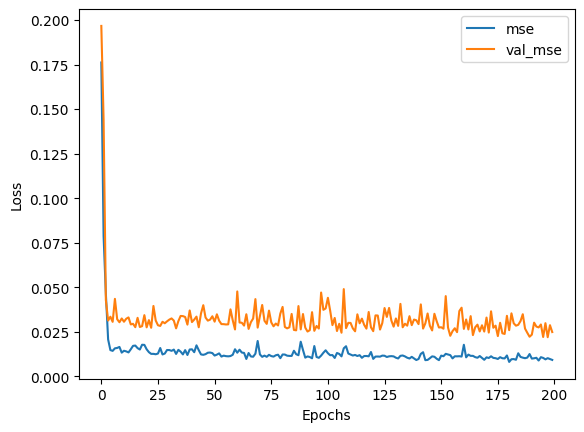

In [9]:
# Visualize training and validation loss
import matplotlib.pyplot as plt
lstm_train_loss = lstm_history.history['loss']
lstm_val_loss = lstm_history.history['val_loss']
plt.plot(lstm_train_loss)
plt.plot(lstm_val_loss)
# plt.plot(lstm_history.history['mse'])
# plt.plot(lstm_history.history['val_mse'])
plt.legend(['mse','val_mse'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [10]:
## predict with the training set
Y_train_3D_pred_list = {}
for bearing in bearing_list[idx_train]:
    Y_train_3D_pred_list[bearing] = regressor.predict(X_train_3D_list[bearing])


9/9 [==============================] - 0s 2ms/step


In [11]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

Y_train_3D_mse_list = {}
Y_train_3D_mae_list = {}
Y_train_3D_mape_list = {}
for bearing in bearing_list[idx_train]:
    y_true = Y_train_3D_list[bearing]
    y_pred = Y_train_3D_pred_list[bearing]
    Y_train_3D_mse_list[bearing] = mean_squared_error(y_true, y_pred)
    Y_train_3D_mae_list[bearing] = mean_absolute_error(y_true, y_pred)
    Y_train_3D_mape_list[bearing] = mean_absolute_percentage_error(y_true, y_pred)
    print(bearing, Y_train_3D_mse_list[bearing], Y_train_3D_mae_list[bearing], Y_train_3D_mape_list[bearing])


Bearing3_1 0.002408537682144698 0.034786288963677706 0.14761400746768027
Bearing3_2 0.00886117293175191 0.07137725026305462 0.17911814969272366


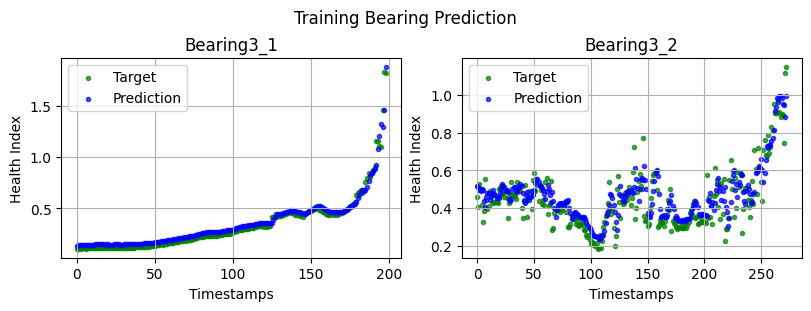

In [12]:
import matplotlib.pyplot as plt
## two training bearings
fig, axs = plt.subplots(1,2, figsize=(8,3), layout='constrained')  
# fig, ax = plt.subplots(1,1, figsize=(8,3), layout='constrained')  

for i, ax in enumerate(axs.flat):
    bearing = bearing_list[idx_train][i]
    ax.scatter(list(range(Y_train_3D_list[bearing].shape[0])),Y_train_3D_list[bearing], 
               marker = '.', color='green', alpha = 0.7, label='Target')
    ax.scatter(list(range(Y_train_3D_list[bearing].shape[0])),Y_train_3D_pred_list[bearing][:,0],
               marker = '.', color='blue', alpha = 0.7, label='Prediction')
    ax.set_title(bearing)
    ax.legend()
    ax.grid(True)
    # ax.set_ylim(-0.005,0.06)
    ax.set_xlabel('Timestamps')
    ax.set_ylabel('Health Index')
plt.suptitle('Training Bearing Prediction')
plt.show()


### Testing

In [13]:
## iteratively prediction
def rul_prediction(X_test, ts_input):
    i = 0
    index_pred = 0
    index_pred_list2 = []
    while index_pred < 1:
        if i%10 == 0:
            print(i)
        if i == 100:
            break
        if i == 0:
            vector = np.array(X_test) ## start from the last input vector that early fault detected
        else:
            vector = np.append(vector[1:],index_pred) ## remove the first element and append the prediction 
        index_pred = regressor.predict(vector.reshape((1,ts_input,1)))
        index_pred_list2.append(index_pred[0][0])
        i+=1
    return index_pred_list2
index_pred_list = {}    
for bearing in bearing_list[idx_test]:
    print(f'% ------------------- {bearing} ------------------- %')
    index_pred_list[bearing] = rul_prediction(X_test_3D_list[bearing][0,:,:], ts_input)


% ------------------- Bearing3_3 ------------------- %
0
1/1 [==============================] - 0s 24ms/step
10
1/1 [==============================] - 0s 24ms/step
20
1/1 [==============================] - 0s 24ms/step
% ------------------- Bearing3_4 ------------------- %
0
1/1 [==============================] - 0s 25ms/step
10
1/1 [==============================] - 0s 25ms/step
20
1/1 [==============================] - 0s 25ms/step
30
1/1 [==============================] - 0s 24ms/step
40
1/1 [==============================] - 0s 25ms/step
50
1/1 [==============================] - 0s 24ms/step
60
1/1 [==============================] - 0s 24ms/step


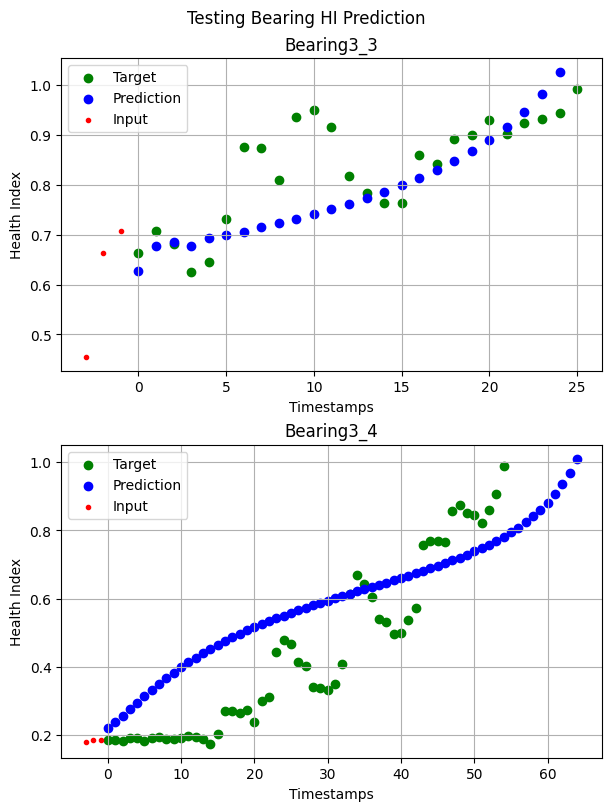

In [14]:
import matplotlib.pyplot as plt
## two testing bearings
fig, axs = plt.subplots(2,1, figsize=(6,8), layout='constrained')  
# fig, ax = plt.subplots(1,1, figsize=(8,3), layout='constrained')  
for i, ax in enumerate(axs.flat):
    bearing = bearing_list[idx_test][i]

    ax.scatter(list(range(Y_test_list[bearing].shape[0])),Y_test_list[bearing].values, color='green', label='Target')
    ax.scatter(list(range(len(index_pred_list[bearing]))),index_pred_list[bearing], color='blue', label='Prediction')
    ax.scatter(list(range(-ts_input,0)),X_test_3D_list[bearing][0,:,:], marker = '.', color = 'red', label = 'Input')
    ax.set_title(bearing)
    ax.legend()
    ax.grid(True)
    # ax.set_ylim(-0.005,0.06)
    ax.set_xlabel('Timestamps')
    ax.set_ylabel('Health Index')
plt.suptitle('Testing Bearing HI Prediction')
plt.show()


In [15]:
for bearing in bearing_list[idx_test]:
    rul_pred = len(index_pred_list[bearing])
    rul_true = Y_test_list[bearing].shape[0]
    percentage = rul_pred/rul_true*100
    print(f'{bearing} estimated RUL = {rul_pred}, {round(percentage, 2)}% of actual RUL = {rul_true}')

print('---------------------------------------------')
for bearing in bearing_list[idx_test]:    
    rul_pred = len(index_pred_list[bearing])
    rul_true = Y_test_list[bearing].shape[0]
    filename = os.path.join(root,bearing+'_RMS.csv')
    df = pd.read_csv(filename)
    lifetime = len(df)
    percentage_lifetime = rul_pred/lifetime*100
    print(f'{bearing} estimated RUL = {rul_pred}, {round(percentage_lifetime, 2)}% of actual Lifetime = {lifetime}')


Bearing3_3 estimated RUL = 25, 96.15% of actual RUL = 26
Bearing3_4 estimated RUL = 65, 118.18% of actual RUL = 55
---------------------------------------------
Bearing3_3 estimated RUL = 25, 6.74% of actual Lifetime = 371
Bearing3_4 estimated RUL = 65, 4.29% of actual Lifetime = 1515


In [16]:
## score of PHM Challenge
import numpy as np
def score(rul_true, rul_pred):
    error = 100*(rul_true-rul_pred)/rul_true
    if error<=0:
        accuracy = np.exp(-np.log(0.5)*error/5)
    else:
        accuracy = np.exp(np.log(0.5)*error/20)
    return accuracy

accuracy = {}
for bearing in bearing_list[idx_test]:
    rul_pred = len(index_pred_list[bearing])
    rul_true = Y_test_list[bearing].shape[0]
    accuracy[bearing] = score(rul_true, rul_pred)
    print(f'{bearing} score = {round(accuracy[bearing], 2)}')
print(f'overall score = {np.mean([accuracy[bearing] for bearing in bearing_list[idx_test]])}')    

Bearing3_3 score = 0.88
Bearing3_4 score = 0.08
overall score = 0.47781060285894655


In [17]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

Y_test_3D_mse_list = {}
Y_test_3D_mae_list = {}
Y_test_3D_mape_list = {}
for bearing in bearing_list[idx_test]:
    y_true = Y_test_list[bearing].values[:min(len(index_pred_list[bearing]),len(Y_test_list[bearing]))]
    y_pred = index_pred_list[bearing][:min(len(index_pred_list[bearing]),len(Y_test_list[bearing]))]
    Y_test_3D_mse_list[bearing] = mean_squared_error(y_true, y_pred)
    Y_test_3D_mae_list[bearing] = mean_absolute_error(y_true, y_pred)
    Y_test_3D_mape_list[bearing] = mean_absolute_percentage_error(y_true, y_pred)
    print(bearing, Y_test_3D_mse_list[bearing], Y_test_3D_mae_list[bearing], Y_test_3D_mape_list[bearing])


Bearing3_3 0.008113510966273241 0.06627666983569885 0.0772866708468715
Bearing3_4 0.027753868014015373 0.14900807233393695 0.5006932576599926


### Continuous testing

In [18]:
## iteratively prediction
def rul_prediction_silence(X_test, ts_input):
    i = 0
    index_pred = 0
    index_pred_list2 = []
    while index_pred < 1:
        if i%10 == 0:
            print(i)
        if i == 100:
            break
        if i == 0:
            vector = np.array(X_test) ## start from the last input vector that early fault detected
        else:
            vector = np.append(vector[1:],index_pred) ## remove the first element and append the prediction 
        index_pred = regressor.predict(vector.reshape((1,ts_input,1)),verbose=0)
        index_pred_list2.append(index_pred[0][0])
        i+=1
    return index_pred_list2
index_pred_list = {}    
for bearing in bearing_list[idx_test]:
    for i in range(X_test_3D_list[bearing].shape[0]):
        idx = f'{bearing}_{i}'
        print(f'% ------------------- {idx} ------------------- %')
        index_pred_list[idx] = rul_prediction_silence(X_test_3D_list[bearing][i,:,:], ts_input)


% ------------------- Bearing3_3_0 ------------------- %
0
10
20
% ------------------- Bearing3_3_1 ------------------- %
0
10
% ------------------- Bearing3_3_2 ------------------- %
0
10
20
% ------------------- Bearing3_3_3 ------------------- %
0
10
20
% ------------------- Bearing3_3_4 ------------------- %
0
10
% ------------------- Bearing3_3_5 ------------------- %
0
% ------------------- Bearing3_3_6 ------------------- %
0
% ------------------- Bearing3_3_7 ------------------- %
0
% ------------------- Bearing3_3_8 ------------------- %
0
% ------------------- Bearing3_3_9 ------------------- %
0
% ------------------- Bearing3_3_10 ------------------- %
0
% ------------------- Bearing3_3_11 ------------------- %
0
% ------------------- Bearing3_3_12 ------------------- %
0
% ------------------- Bearing3_3_13 ------------------- %
0
% ------------------- Bearing3_3_14 ------------------- %
0
10
% ------------------- Bearing3_3_15 ------------------- %
0
% ------------------- B

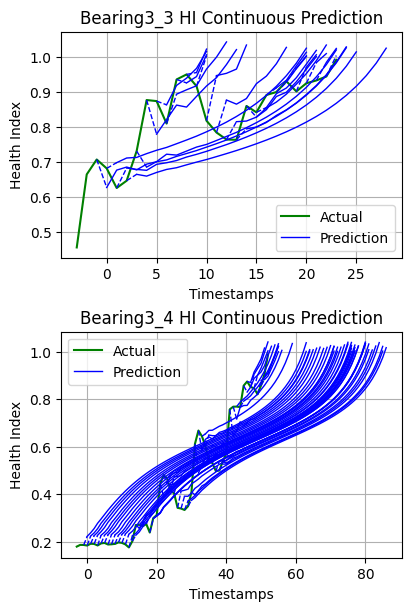

In [19]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
## two testing bearings
# pdf_filename = "MXWSE HI Continuous Prediction.pdf"
# with PdfPages(pdf_filename) as pdf:
fig, axs = plt.subplots(2,1, figsize=(4,6), layout='constrained')  
# fig, ax = plt.subplots(1,1, figsize=(8,3), layout='constrained')  
for i, ax in enumerate(axs.flat):
    bearing = bearing_list[idx_test[i]]
    actual = np.append(X_test_3D_list[bearing][0,0,0],Y_test_list[bearing].values)
    ax.plot(list(range(-X_test_3D_list[bearing].shape[1],len(actual)-X_test_3D_list[bearing].shape[1])),actual,color='green', label='Actual')
    for j in range(X_test_3D_list[bearing].shape[0]):
        idx = f'{bearing}_{j}'
        if j==0:
            # ax.plot(list(range(j-ts_input+1,j+1)),X_test_3D_list[bearing][j,:,:], color = 'red', label = 'Input')#, marker = '.'
            # ax.plot(list(range(j-1,j+1)),[X_test_3D_list[bearing][j,-1,0],index_pred_list[idx][0]], '--' ,linewidth=1, color='blue')
            ax.plot(list(range(j,j+len(index_pred_list[idx]))),index_pred_list[idx], 
                       linewidth=1, color='blue', label='Prediction')
            ax.plot(list(range(j-1,j+1)),[X_test_3D_list[bearing][j,-1,0],index_pred_list[idx][0]], '--' ,linewidth=1, color='blue')
        else:
            # ax.plot(list(range(j-ts_input,j)),X_test_3D_list[bearing][j,:,:], color = 'red')#, marker = '.'
            # ax.plot(list(range(j-1,j+1)),[X_test_3D_list[bearing][j,-1,0],index_pred_list[idx][0]], '--' ,linewidth=1, color='blue')
            ax.plot(list(range(j,j+len(index_pred_list[idx]))),index_pred_list[idx], 
                       linewidth=1, color='blue')
            ax.plot(list(range(j-1,j+1)),[X_test_3D_list[bearing][j,-1,0],index_pred_list[idx][0]], '--' ,linewidth=1, color='blue')
    ax.set_title(bearing+' HI Continuous Prediction')
    ax.legend()
    ax.grid(True)
    # ax.set_ylim(-0.005,0.06)
    ax.set_xlabel('Timestamps')
    ax.set_ylabel('Health Index')
    # pdf.savefig()
# plt.suptitle('Testing Bearing HI Prediction')
plt.show()


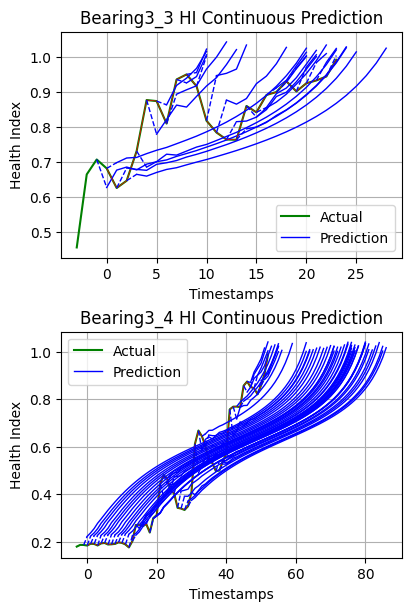

In [20]:
fig, axs = plt.subplots(2,1, figsize=(4,6), layout='constrained')  
for i, ax in enumerate(axs.flat):
    bearing = bearing_list[idx_test[i]]
    actual = np.append(X_test_3D_list[bearing][0,0,0],Y_test_list[bearing].values)
    ax.plot(list(range(-X_test_3D_list[bearing].shape[1],len(actual)-X_test_3D_list[bearing].shape[1])),actual,color='green', label='Actual')
    for j in range(X_test_3D_list[bearing].shape[0]):
        idx = f'{bearing}_{j}'
        if j==0:
            ax.plot(list(range(j,j+len(index_pred_list[idx]))),index_pred_list[idx], 
                       linewidth=1, color='blue', label='Prediction')
            ax.plot(list(range(j,j+len(Y_test_3D_list[bearing][j:]))),Y_test_3D_list[bearing][j:],
                   linewidth=.5, color='red')
            ax.plot(list(range(j-1,j+1)),[X_test_3D_list[bearing][j,-1,0],index_pred_list[idx][0]], '--' ,linewidth=1, color='blue')
        else:
            ax.plot(list(range(j,j+len(index_pred_list[idx]))),index_pred_list[idx], 
                       linewidth=1, color='blue')
            ax.plot(list(range(j-1,j+1)),[X_test_3D_list[bearing][j,-1,0],index_pred_list[idx][0]], '--' ,linewidth=1, color='blue')
    ax.set_title(bearing+' HI Continuous Prediction')
    ax.legend()
    ax.grid(True)
    # ax.set_ylim(-0.005,0.06)
    ax.set_xlabel('Timestamps')
    ax.set_ylabel('Health Index')
plt.show()

In [21]:
for i in range(2):
    bearing = bearing_list[idx_test[i]]
    for j in range(X_test_3D_list[bearing].shape[0]):
        idx = f'{bearing}_{j}'
        Target = pd.DataFrame({'Target RMS':Y_test_3D_list[bearing][j:]})
        Prediction = pd.DataFrame({'Prediction RMS':index_pred_list[idx]})
        file_target = 'HI Prediction/Target_RMS_'+idx+'.csv'
        file_prediction = 'HI Prediction/Prediction_RMS_'+idx+'.csv'
        Target.to_csv(file_target)
        Prediction.to_csv(file_prediction)

In [22]:
## score of PHM Challenge
import numpy as np
def score(rul_true, rul_pred):
    error = 100*(rul_true-rul_pred)/rul_true
    if error<=0:
        accuracy = np.exp(-np.log(0.5)*error/5)
    else:
        accuracy = np.exp(np.log(0.5)*error/20)
    return accuracy

accuracy = {}
avg_score = {}
for bearing in bearing_list[idx_test]:
    for i in range(X_test_3D_list[bearing].shape[0]):
        idx = f'{bearing}_{i}'
        rul_pred = len(index_pred_list[idx])
        rul_true = Y_test_list[bearing][i:].shape[0]
        accuracy[idx] = score(rul_true, rul_pred)
        print(f'{idx} score = {round(accuracy[idx], 2)}')
    avg_score[bearing] = np.mean([accuracy[f'{bearing}_{i}'] for i in range(X_test_3D_list[bearing].shape[0])])
for bearing in bearing_list[idx_test]:
    print(f'{bearing} score = {avg_score[bearing]}')
print(f'overall score = {np.mean([avg_score[bearing] for bearing in bearing_list[idx_test]])}')    

Bearing3_3_0 score = 0.88
Bearing3_3_1 score = 0.5
Bearing3_3_2 score = 1.0
Bearing3_3_3 score = 0.16
Bearing3_3_4 score = 0.73
Bearing3_3_5 score = 0.14
Bearing3_3_6 score = 0.07
Bearing3_3_7 score = 0.09
Bearing3_3_8 score = 0.06
Bearing3_3_9 score = 0.05
Bearing3_3_10 score = 0.04
Bearing3_3_11 score = 0.08
Bearing3_3_12 score = 0.18
Bearing3_3_13 score = 0.45
Bearing3_3_14 score = 0.75
Bearing3_3_15 score = 0.28
Bearing3_3_16 score = 0.25
Bearing3_3_17 score = 0.15
Bearing3_3_18 score = 0.11
Bearing3_3_19 score = 0.08
Bearing3_3_20 score = 0.1
Bearing3_3_21 score = 0.13
Bearing3_3_22 score = 0.18
Bearing3_3_23 score = 0.1
Bearing3_4_0 score = 0.08
Bearing3_4_1 score = 0.06
Bearing3_4_2 score = 0.04
Bearing3_4_3 score = 0.03
Bearing3_4_4 score = 0.02
Bearing3_4_5 score = 0.02
Bearing3_4_6 score = 0.01
Bearing3_4_7 score = 0.01
Bearing3_4_8 score = 0.0
Bearing3_4_9 score = 0.0
Bearing3_4_10 score = 0.0
Bearing3_4_11 score = 0.0
Bearing3_4_12 score = 0.0
Bearing3_4_13 score = 0.0
Bear